# EduPro Predictive Modeling for Course Demand and Revenue Forecasting

**Unified Mentor Data Analyst Internship**  
**Prepared by: Aman Jat**

This notebook converts EduPro's historical course data into forward-looking intelligence. It predicts next-month enrollment demand, course revenue, and category revenue using a time-based validation design.

In [ ]:
%pip install -r requirements.txt

## 1. Problem Statement

EduPro currently lacks:

- predictive models for course-enrollment demand;
- revenue forecasting at course and category levels; and
- quantitative evidence for course-launch and pricing decisions.

The goal is to move from reactive historical reporting to proactive course, pricing, instructor, and resource planning.

In [4]:
from pathlib import Path
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from train_models import (
    build_course_month_dataset, build_category_month_dataset,
    evaluate_models, importance_table, FEATURES, NUMERIC_FEATURES,
    CATEGORICAL_FEATURES, CATEGORY_FEATURES, CATEGORY_NUMERIC,
    CATEGORY_CATEGORICAL
)

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
BASE = Path.cwd()
print('Working directory:', BASE)

Working directory: c:\New project


## 2. Load and Inspect the Source Data

The project uses Courses, Teachers, Transactions, and Users datasets. Transactions are parsed as dates before monthly aggregation.

In [5]:
courses = pd.read_csv(BASE / 'EduPro Online Platform.xlsx - Courses.csv')
teachers = pd.read_csv(BASE / 'EduPro Online Platform.xlsx - Teachers.csv')
transactions = pd.read_csv(BASE / 'EduPro Online Platform.xlsx - Transactions.csv')
users = pd.read_csv(BASE / 'EduPro Online Platform.xlsx - Users.csv')

summary = pd.DataFrame({
    'Dataset': ['Users', 'Courses', 'Teachers', 'Transactions'],
    'Rows': [len(users), len(courses), len(teachers), len(transactions)],
    'Columns': [users.shape[1], courses.shape[1], teachers.shape[1], transactions.shape[1]],
})
display(summary)
display(courses.head())

,Dataset,Rows,Columns
0,Users,3000,5
1,Courses,60,8
2,Teachers,60,7
3,Transactions,10000,7


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28


## 3. Data Preparation and Feature Engineering

To prevent leakage, each row represents one course and one historical month. Inputs use information available in that month; targets are shifted to the following month.

Engineered features include price bands, duration buckets, rating tiers, course level/category, instructor-experience buckets, teacher rating, expertise-category match, past enrollment count, historical average revenue, and revenue per enrollment.

In [6]:
course_panel = build_course_month_dataset()
category_panel = build_category_month_dataset(course_panel)

print('Course-month modeling rows:', course_panel.shape)
print('Category-month modeling rows:', category_panel.shape)
display(course_panel.head())
display(course_panel[['Month','ForecastMonth','PastEnrollmentCount','TargetEnrollmentCount','CurrentRevenue','TargetCourseRevenue']].tail())

Course-month modeling rows: (660, 25)
Category-month modeling rows: (132, 12)


,CourseID,Month,CurrentEnrollments,CurrentRevenue,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating,YearsOfExperience,TeacherRating,ExpertiseCategoryMatch,PastEnrollmentCount,PastAverageRevenue,RevenuePerEnrollment,TargetEnrollmentCount,TargetCourseRevenue,ForecastMonth,MonthNumber,PriceBand,DurationBucket,RatingTier,ExperienceBucket
0,CR00001,2025-01,18,8501.04,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,16.682927,4.191646,0.134146,18,8501.040000,472.28,11.0,5195.08,2025-02,2,High,Short,Excellent,Senior
1,CR00001,2025-02,11,5195.08,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,16.682927,4.191646,0.134146,11,6848.060000,472.28,8.0,3778.24,2025-03,3,High,Short,Excellent,Senior
2,CR00001,2025-03,8,3778.24,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,16.682927,4.191646,0.134146,8,5824.786667,472.28,14.0,6611.92,2025-04,4,High,Short,Excellent,Senior
3,CR00001,2025-04,14,6611.92,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,16.682927,4.191646,0.134146,14,6021.570000,472.28,17.0,8028.76,2025-05,5,High,Short,Excellent,Senior
4,CR00001,2025-05,17,8028.76,Python Basics,Programming,Paid,Beginner,472.28,11.0,4.74,16.682927,4.191646,0.134146,17,6423.008000,472.28,11.0,5195.08,2025-06,6,High,Short,Excellent,Senior


,Month,ForecastMonth,PastEnrollmentCount,TargetEnrollmentCount,CurrentRevenue,TargetCourseRevenue
655,2025-07,2025-08,11,13.0,0.0,0.0
656,2025-08,2025-09,13,13.0,0.0,0.0
657,2025-09,2025-10,13,15.0,0.0,0.0
658,2025-10,2025-11,15,12.0,0.0,0.0
659,2025-11,2025-12,12,21.0,0.0,0.0


### Leakage Control

The earlier version repeated each course's total enrollment across transaction rows and randomly split those transactions. This allowed the same course to appear in both training and testing, producing an unrealistic perfect score. The revised design trains on forecast months February–October and holds out November–December as unseen future periods.

## 4. Exploratory Analysis

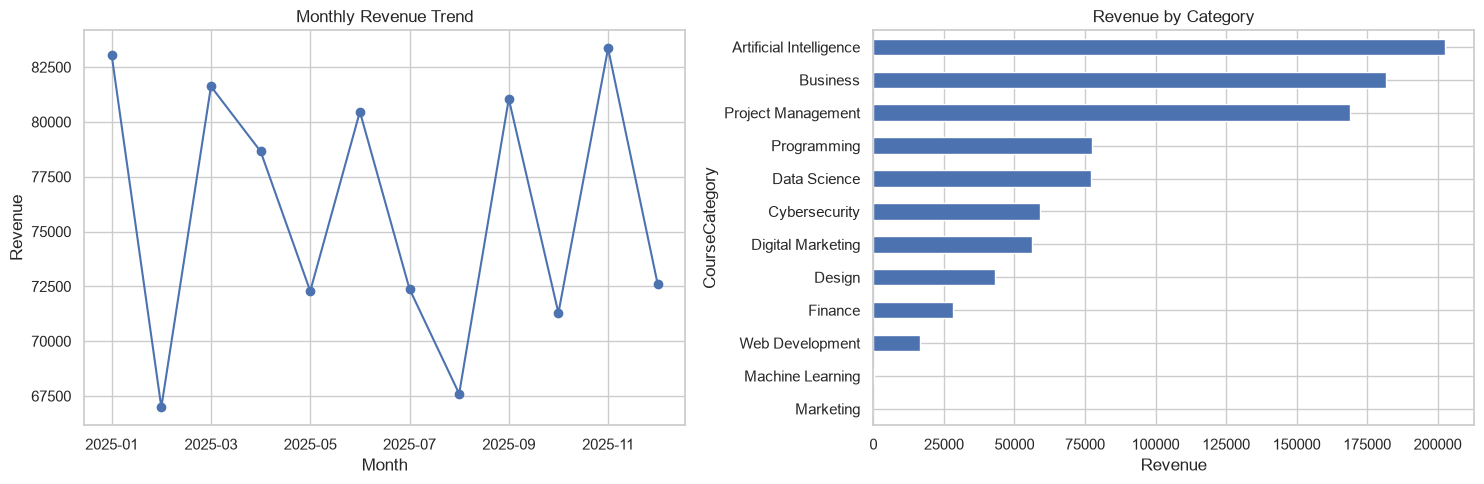

,Enrollments,Revenue
CourseName,,
Deep Learning,334,67861.51
Natural Language Processing,321,14871.94
Data Analysis with Python,196,0.00
Social Media Strategy,194,0.00
Statistical Analysis,192,57517.44
AI Ethics,186,0.00
Machine Learning Fundamentals,185,0.00
Investment Strategies,183,0.00
Corporate Finance,182,0.00


In [7]:
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'], dayfirst=True)
merged = transactions.merge(courses, on='CourseID', how='left')
merged['Month'] = merged['TransactionDate'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
merged.groupby('Month')['Amount'].sum().plot(marker='o', ax=axes[0], title='Monthly Revenue Trend')
merged.groupby('CourseCategory')['Amount'].sum().sort_values().plot(kind='barh', ax=axes[1], title='Revenue by Category')
axes[0].set_ylabel('Revenue'); axes[1].set_xlabel('Revenue')
plt.tight_layout(); plt.show()

display(merged.groupby('CourseName').agg(Enrollments=('TransactionID','count'),Revenue=('Amount','sum')).sort_values('Enrollments',ascending=False).head(10))

## 5. Model Development and Comparison

Five regressors are compared for each target: Linear Regression, Ridge, Lasso, Random Forest, and Gradient Boosting. Metrics are MAE, RMSE, and R². The lowest holdout RMSE determines the saved model.

In [8]:
demand_metrics, demand_model, demand_best, _ = evaluate_models(
    course_panel, FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    'TargetEnrollmentCount', 'Enrollment Demand')
revenue_metrics, revenue_model, revenue_best, _ = evaluate_models(
    course_panel, FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    'TargetCourseRevenue', 'Course Revenue')
category_metrics, category_model, category_best, _ = evaluate_models(
    category_panel, CATEGORY_FEATURES, CATEGORY_NUMERIC, CATEGORY_CATEGORICAL,
    'TargetCategoryRevenue', 'Category Revenue')

metrics = pd.concat([demand_metrics, revenue_metrics, category_metrics], ignore_index=True)
display(metrics.sort_values(['Task','RMSE']))
print('Best demand model:', demand_best)
print('Best course-revenue model:', revenue_best)
print('Best category-revenue model:', category_best)

,Task,Model,MAE,RMSE,R2,TrainRows,TestRows
10,Category Revenue,Ridge Regression,910.979912,1539.612304,0.932937,108,24
11,Category Revenue,Lasso Regression,959.254065,1579.629084,0.929406,108,24
12,Category Revenue,Linear Regression,959.586193,1579.946629,0.929378,108,24
13,Category Revenue,Random Forest,1049.094921,1804.756472,0.907850,108,24
14,Category Revenue,Gradient Boosting,1322.967231,2307.387816,0.849375,108,24
5,Course Revenue,Ridge Regression,256.169176,536.738451,0.940922,540,120
6,Course Revenue,Lasso Regression,259.251904,539.302882,0.940356,540,120
7,Course Revenue,Linear Regression,259.295323,540.063990,0.940188,540,120
8,Course Revenue,Gradient Boosting,236.483263,585.240622,0.929763,540,120
9,Course Revenue,Random Forest,279.336186,640.768231,0.915802,540,120


Best demand model: Ridge Regression
Best course-revenue model: Ridge Regression
Best category-revenue model: Ridge Regression


### Model Interpretation

The revenue targets are strongly predictable because course price and recent revenue contain useful forward-looking signals. Enrollment demand is much harder: the supplied synthetic transactions contain weak month-to-month demand structure. Reporting this low demand R² is more credible than using a leakage-prone split that creates R² = 1.00.

,Task,Model,MAE,RMSE,R2,TrainRows,TestRows
0,Category Revenue,Ridge Regression,910.979912,1539.612304,0.932937,108,24
1,Course Revenue,Ridge Regression,256.169176,536.738451,0.940922,540,120
2,Enrollment Demand,Ridge Regression,2.778886,3.651692,0.013811,540,120


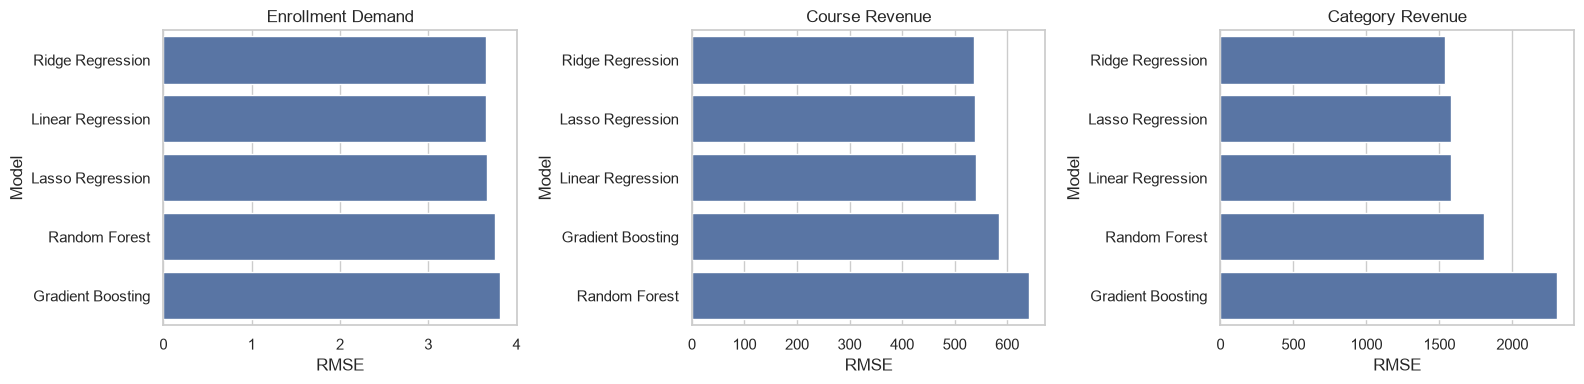

In [9]:
best = metrics.sort_values('RMSE').groupby('Task', as_index=False).first()
display(best[['Task','Model','MAE','RMSE','R2','TrainRows','TestRows']])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, task in zip(axes, ['Enrollment Demand','Course Revenue','Category Revenue']):
    part = metrics[metrics.Task == task].sort_values('RMSE')
    sns.barplot(data=part, x='RMSE', y='Model', ax=ax)
    ax.set_title(task)
plt.tight_layout(); plt.show()

## 6. Feature Importance

,Task,Feature,Importance
0,Enrollment Demand,CourseCategory_Data Science,1.479832
1,Enrollment Demand,PastAverageRevenue,1.326056
2,Enrollment Demand,PriceBand_High,1.209675
3,Enrollment Demand,CourseCategory_Cybersecurity,0.907899
4,Enrollment Demand,PriceBand_Low,0.899775
5,Enrollment Demand,CourseCategory_Finance,0.889608
6,Enrollment Demand,CourseCategory_Marketing,0.857730
7,Enrollment Demand,CourseCategory_Programming,0.834099
8,Enrollment Demand,CourseCategory_Digital Marketing,0.697325
9,Enrollment Demand,CourseLevel_Intermediate,0.595272


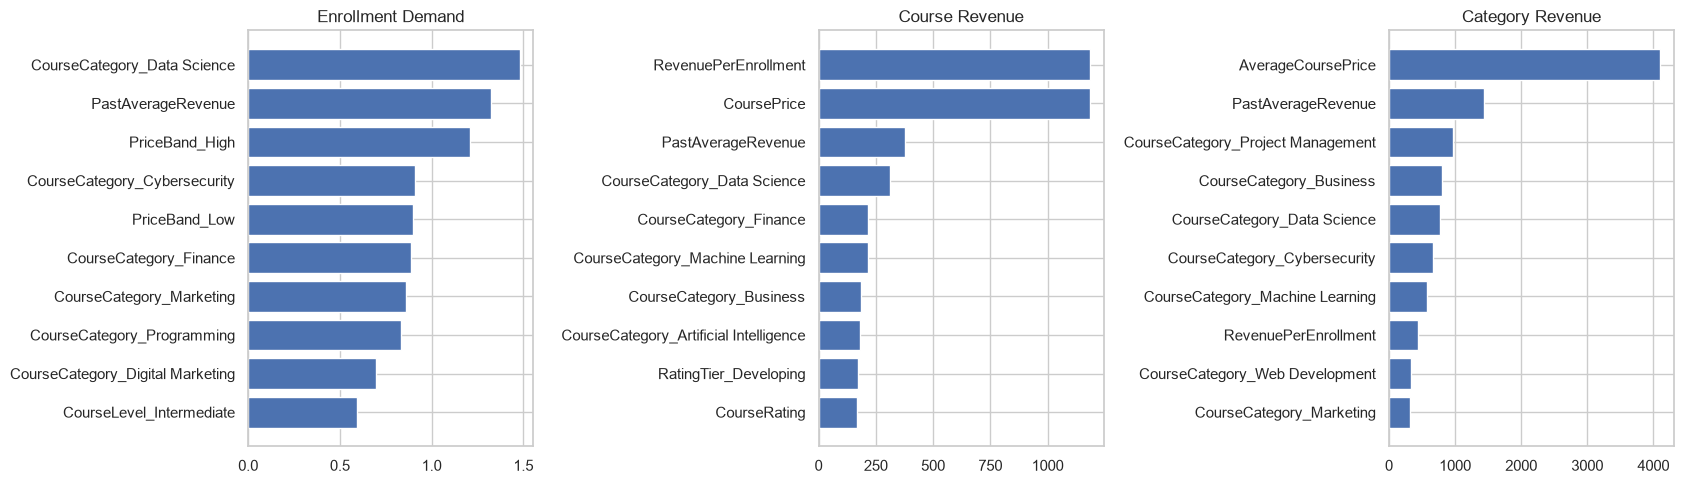

In [10]:
importance = pd.concat([
    importance_table(demand_model, NUMERIC_FEATURES, CATEGORICAL_FEATURES, 'Enrollment Demand'),
    importance_table(revenue_model, NUMERIC_FEATURES, CATEGORICAL_FEATURES, 'Course Revenue'),
    importance_table(category_model, CATEGORY_NUMERIC, CATEGORY_CATEGORICAL, 'Category Revenue'),
], ignore_index=True)

display(importance.groupby('Task').head(10))
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, task in zip(axes, importance.Task.unique()):
    part = importance[importance.Task == task].nlargest(10, 'Importance').sort_values('Importance')
    ax.barh(part.Feature, part.Importance)
    ax.set_title(task)
plt.tight_layout(); plt.show()

## 7. Save Deployment Artifacts

The training script saves one bundle containing the three selected pipelines plus metrics, importance tables, and modeling datasets. Run the cell below whenever source data or model settings change.

In [11]:
from train_models import main
main()
print('Deployment artifacts created successfully.')

             Task             Model         MAE        RMSE        R2  TrainRows  TestRows
Enrollment Demand  Ridge Regression    2.778886    3.651692  0.013811        540       120
Enrollment Demand Linear Regression    2.789490    3.652572  0.013336        540       120
Enrollment Demand  Lasso Regression    2.765024    3.661499  0.008506        540       120
Enrollment Demand     Random Forest    2.900362    3.759909 -0.045506        540       120
Enrollment Demand Gradient Boosting    2.828238    3.813846 -0.075718        540       120
   Course Revenue  Ridge Regression  256.169176  536.738451  0.940922        540       120
   Course Revenue  Lasso Regression  259.251904  539.302882  0.940356        540       120
   Course Revenue Linear Regression  259.295323  540.063990  0.940188        540       120
   Course Revenue Gradient Boosting  236.483263  585.240622  0.929763        540       120
   Course Revenue     Random Forest  279.336186  640.768231  0.915802        540       120

## 8. Key Business Findings and Recommendations

- Artificial Intelligence is the strongest historical revenue category.
- Deep Learning has the highest historical enrollment demand.
- Computer Vision is among the strongest individual courses by revenue.
- Payment-method revenue is nearly balanced across PayPal, Bank Transfer, and Credit Card.
- EduPro should compare enrollment and revenue together when planning its portfolio.
- Category forecasts can support content-roadmap and resource-allocation decisions.
- Pricing experiments should be monitored using forecast-versus-actual revenue.
- Model performance should be retrained and monitored as new monthly data becomes available.

## 9. Conclusion

The revised project transforms EduPro's historical data into forward-looking intelligence. It forecasts course demand, course revenue, and category revenue; evaluates five regression approaches with a future-period holdout; exposes feature importance; and deploys the results in Streamlit. The system can support course-roadmap planning, pricing, instructor allocation, and more evidence-based launch decisions.